<a href="https://colab.research.google.com/github/samirapilfree5-creator/Code-sql/blob/main/Tp2_Label.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lab 2 — Health Data Modelling

## Préparation — imports et dataset d’exemple

## ETAPE 1 : PREPARATION DES BIBLIOTHEQUES ET DE LA DATASET

In [1]:
import re
import time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, make_scorer)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.decomposition import TruncatedSVD

RANDOM_STATE = 42

data = pd.DataFrame({
    "text": [
        "i didnt feel humiliated",
        "i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and ...",
        "im grabbing a minute to post i feel greedy wrong",
        "i am ever feeling nostalgic about the fireplace i will know that it is still on the property",
        "i am feeling grouchy",
        "ive been feeling a little burdened lately wasnt sure why that was",
        "ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i a...",
        "i feel as confused about life as a teenager or as jaded as a year old man"
    ],
    "label": [0, 0, 3, 2, 3, 0, 5, 4]
})
print("Dataset d’exemple :", data.shape)
data

Dataset d’exemple : (8, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,0
6,ive been taking or milligrams or times recomme...,5
7,i feel as confused about life as a teenager or...,4


# SECTION 1: Prétraitement et représentations

# Q1-Suppressions des mots stops

In [2]:
import spacy
nlp = spacy.blank("en")
stop_words = nlp.Defaults.stop_words

def remove_stop_words(text):
    doc = nlp(str(text))
    return [token.text for token in doc if token.text.lower() not in stop_words]

example = "The researchers are developing advanced algorithms."
print(remove_stop_words(example))
# Sortie attendue : ['researchers', 'developing', 'advanced', 'algorithms', '.']

['researchers', 'developing', 'advanced', 'algorithms', '.']


# Q2-Application de la fonction

In [3]:
data["tokens_without_stopwords"] = data["text"].apply(remove_stop_words)
data["text_clean"] = data["tokens_without_stopwords"].apply(lambda tokens: " ".join(tokens))
display(data[["text", "text_clean", "label"]])

,text,text_clean,label
0,i didnt feel humiliated,nt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,feeling hopeless damned hopeful cares ...,0
2,im grabbing a minute to post i feel greedy wrong,m grabbing minute post feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,feeling nostalgic fireplace know property,2
4,i am feeling grouchy,feeling grouchy,3
5,ive been feeling a little burdened lately wasn...,ve feeling little burdened lately nt sure,0
6,ive been taking or milligrams or times recomme...,ve taking milligrams times recommended ve fall...,5
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man,4


# Q3-Comptage des occurences

In [4]:
def count_words(sentence):
    tokens = re.findall(r"\b[\w']+\b", str(sentence).lower())
    return dict(Counter(tokens))

print(count_words("The doctor helped the patient; the doctor smiled."))

{'the': 3, 'doctor': 2, 'helped': 1, 'patient': 1, 'smiled': 1}


# Q4-Construire BoW manuellement

In [5]:
all_word_counts = [count_words(text) for text in data["text_clean"]]
vocabulary = sorted(set(word for counts in all_word_counts for word in counts))
bow_manual = np.array([[counts.get(word, 0) for word in vocabulary] for counts in all_word_counts])
bow_manual_df = pd.DataFrame(bow_manual, columns=vocabulary)
print("Dimensions :", bow_manual_df.shape)
display(bow_manual_df)

Dimensions : (8, 39)


,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6,1,0,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,1,2,0,0
7,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


# Q5-BoW avec CountVectorizer

In [6]:
count_vectorizer = CountVectorizer()
X_bow = count_vectorizer.fit_transform(data["text_clean"])
bow_df = pd.DataFrame(X_bow.toarray(), columns=count_vectorizer.get_feature_names_out())
print("Dimensions :", X_bow.shape)
print("Matrice manuelle et CountVectorizer identiques :", np.array_equal(bow_manual, X_bow.toarray()))
display(bow_df)

Dimensions : (8, 38)
Matrice manuelle et CountVectorizer identiques : False


,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
6,1,0,0,0,0,1,1,0,0,0,...,0,0,1,0,1,0,1,2,0,0
7,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


# Q6-TF-IDF manuel

In [7]:
counts = bow_manual.astype(float)
n_documents = counts.shape[0]
total_terms = counts.sum(axis=1, keepdims=True)
tf = np.divide(counts, total_terms, out=np.zeros_like(counts), where=total_terms != 0)
document_frequency = (counts > 0).sum(axis=0)
idf_manual = np.log(n_documents / document_frequency)
tfidf_manual = tf * idf_manual
tfidf_manual_df = pd.DataFrame(tfidf_manual, columns=vocabulary)
display(tfidf_manual_df.round(4))

,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3269,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.0000,0.4159,0.0000,0.4159,0.0000,0.0000,0.0000,0.1386,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1401,0.0000,0.0000,...,0.2971,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2971,0.0000
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1386,0.4159,...,0.0000,0.4159,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3466,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.0000,0.2971,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0990,0.0000,...,0.0000,0.0000,0.0000,0.2971,0.0000,0.0000,0.0000,0.1980,0.0000,0.0000
6,0.2079,0.0000,0.0000,0.0000,0.0000,0.2079,0.2079,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.2079,0.0000,0.2079,0.0000,0.2079,0.2773,0.0000,0.0000
7,0.0000,0.0000,0.0000,0.2599,0.0000,0.0000,0.0000,0.1226,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.2599,0.0000,0.0000,0.0000,0.2599


# Q7-TfidfTransformer

In [8]:
tfidf_transformer = TfidfTransformer()
X_tfidf = tfidf_transformer.fit_transform(X_bow)
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=count_vectorizer.get_feature_names_out())
print("Dimensions :", X_tfidf.shape)
display(tfidf_df.round(4))
print("Différence normale : scikit-learn lisse l’IDF et normalise les lignes par défaut.")

Dimensions : (8, 38)


,asleep,burdened,cares,confused,damned,fallen,faster,feel,feeling,fireplace,...,post,property,recommended,sure,taking,teenager,times,ve,wrong,year
0,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4848,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.0000,0.000,0.4766,0.0000,0.4766,0.0000,0.0000,0.0000,0.3022,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3077,0.0000,0.0000,...,0.4255,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.4255,0.0000
3,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3022,0.4766,...,0.0000,0.4766,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5355,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.0000,0.415,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2631,0.0000,...,0.0000,0.0000,0.0000,0.415,0.0000,0.0000,0.0000,0.3478,0.0000,0.0000
6,0.3042,0.000,0.0000,0.0000,0.0000,0.3042,0.3042,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.3042,0.000,0.3042,0.0000,0.3042,0.5098,0.0000,0.0000
7,0.0000,0.000,0.0000,0.3646,0.0000,0.0000,0.0000,0.2637,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.000,0.0000,0.3646,0.0000,0.0000,0.0000,0.3646


Différence normale : scikit-learn lisse l’IDF et normalise les lignes par défaut.


## Section 2 - Comparaison

# Q8 Analyse exploratoire

Valeurs manquantes :
 Unnamed: 0      0
text          362
target          0
dtype: int64
Doublons exacts : 0
Dimensions après suppression des textes manquants : (52681, 4)


,effectif
target,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


,representation,cv_accuracy_mean,cv_f1_macro_mean,cv_f1_macro_std,cv_f1_weighted_mean
1,TF-IDF,0.6531,0.5856,0.0057,0.6505
0,BoW,0.6508,0.5815,0.0066,0.6472


Représentation retenue par validation croisée : TF-IDF

Résultat final sur le test :
                      precision    recall  f1-score   support

             Anxiety       0.61      0.58      0.59       768
             Bipolar       0.68      0.58      0.63       556
          Depression       0.60      0.60      0.60      3081
              Normal       0.82      0.87      0.84      3269
Personality disorder       0.56      0.48      0.52       215
              Stress       0.41      0.39      0.40       517
            Suicidal       0.54      0.53      0.53      2131

            accuracy                           0.65     10537
           macro avg       0.60      0.58      0.59     10537
        weighted avg       0.65      0.65      0.65     10537

Accuracy : 0.6545


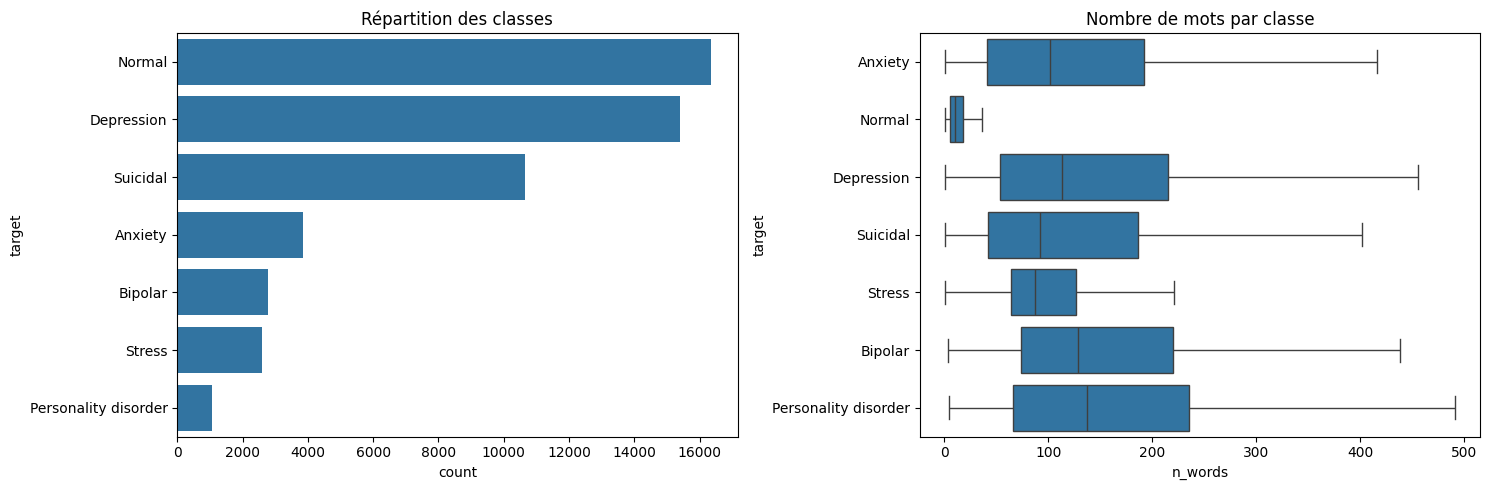

In [9]:
DATA1_URL = "https://raw.githubusercontent.com/EDJINEDJA/Health-Data-modelling/main/lab2/data1/Combined%20Data.csv"
data1 = pd.read_csv(DATA1_URL).rename(columns={"statement": "text", "status": "target"})
print("Valeurs manquantes :\n", data1.isna().sum())
print("Doublons exacts :", data1.duplicated().sum())
data1 = data1.dropna(subset=["text", "target"]).copy()
data1["text"] = data1["text"].astype(str)
data1["n_words"] = data1["text"].str.split().str.len()

print("Dimensions après suppression des textes manquants :", data1.shape)
display(data1["target"].value_counts().rename("effectif").to_frame())
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=data1, y="target", order=data1["target"].value_counts().index, ax=ax[0])
sns.boxplot(data=data1, x="n_words", y="target", ax=ax[1], showfliers=False)
ax[0].set_title("Répartition des classes")
ax[1].set_title("Nombre de mots par classe")
plt.tight_layout()

X_train_text, X_test_text, y_train, y_test = train_test_split(
    data1["text"], data1["target"], test_size=0.20,
    random_state=RANDOM_STATE, stratify=data1["target"]
)

# Même arbre, mêmes paramètres et même vocabulaire maximal pour une comparaison équitable.
# Le vectoriseur est dans le Pipeline : il est réappris dans chaque pli CV.
models_q8 = {
    "BoW": Pipeline([
        ("vectorizer", CountVectorizer(stop_words="english", min_df=5, max_features=3000)),
        ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),
    "TF-IDF": Pipeline([
        ("vectorizer", TfidfVectorizer(stop_words="english", min_df=5, max_features=3000)),
        ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])
}
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models_q8.items():
    scores = cross_validate(model, X_train_text, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({"representation": name,
                    "cv_accuracy_mean": scores["test_accuracy"].mean(),
                    "cv_f1_macro_mean": scores["test_f1_macro"].mean(),
                    "cv_f1_macro_std": scores["test_f1_macro"].std(),
                    "cv_f1_weighted_mean": scores["test_f1_weighted"].mean()})
cv_table = pd.DataFrame(cv_rows).sort_values("cv_f1_macro_mean", ascending=False)
display(cv_table.round(4))
BEST_REPRESENTATION = cv_table.iloc[0]["representation"]
print("Représentation retenue par validation croisée :", BEST_REPRESENTATION)

# Évaluation finale indépendante sur test.
selected_model = models_q8[BEST_REPRESENTATION]
start = time.perf_counter(); selected_model.fit(X_train_text, y_train)
q8_train_time = time.perf_counter() - start
q8_pred = selected_model.predict(X_test_text)
print("\nRésultat final sur le test :")
print(classification_report(y_test, q8_pred, zero_division=0))
print("Accuracy :", round(accuracy_score(y_test, q8_pred), 4))

## Section 3 / Dataset 2

# Q9-Decision tree, Bagging, Boostong et Stacking

In [10]:
BASE2 = "https://raw.githubusercontent.com/EDJINEDJA/Health-Data-modelling/main/lab2/data2/Medical-Abstracts-TC-Corpus-main/"
train2 = pd.read_csv(BASE2 + "medical_tc_train.csv")
test2 = pd.read_csv(BASE2 + "medical_tc_test.csv")
labels2 = pd.read_csv(BASE2 + "medical_tc_labels.csv")
print("Train :", train2.shape, "| Test :", test2.shape)
display(labels2)
display(train2["condition_label"].value_counts().sort_index().rename("effectif").to_frame())

# La représentation choisie en Q8 est réapprise uniquement sur le train de Dataset 2.
if BEST_REPRESENTATION == "BoW":
    vectorizer2 = CountVectorizer(stop_words="english", min_df=2, max_features=3000)
else:
    vectorizer2 = TfidfVectorizer(stop_words="english", min_df=2, max_features=3000, sublinear_tf=True)
X2_train = vectorizer2.fit_transform(train2["medical_abstract"].astype(str))
X2_test = vectorizer2.transform(test2["medical_abstract"].astype(str))
y2_train = train2["condition_label"]
y2_test = test2["condition_label"]

# AdaBoost travaille plus facilement sur une matrice dense de dimension contrôlée.
n_components = min(150, X2_train.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X2_train_svd = svd.fit_transform(X2_train)
X2_test_svd = svd.transform(X2_test)

models_q9 = {
    "Decision Tree": (DecisionTreeClassifier(max_depth=40, min_samples_leaf=2, random_state=RANDOM_STATE), X2_train, X2_test),
    "Bagging": (BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=20, min_samples_leaf=2, random_state=RANDOM_STATE), n_estimators=30, random_state=RANDOM_STATE, n_jobs=-1), X2_train, X2_test),
    "Boosting (AdaBoost)": (AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE), n_estimators=80, learning_rate=0.5, random_state=RANDOM_STATE), X2_train_svd, X2_test_svd),
    "Stacking": (StackingClassifier(estimators=[("logreg", LogisticRegression(max_iter=400, C=2.0)), ("svm", LinearSVC(C=1.0))], final_estimator=LogisticRegression(max_iter=400), cv=3, n_jobs=-1), X2_train, X2_test)
}

q9_results = []
for name, (model, Xtr, Xte) in models_q9.items():
    start = time.perf_counter()
    model.fit(Xtr, y2_train)
    elapsed = time.perf_counter() - start
    pred = model.predict(Xte)
    p, r, f, _ = precision_recall_fscore_support(y2_test, pred, average="macro", zero_division=0)
    q9_results.append({"model": name, "accuracy": accuracy_score(y2_test, pred), "precision_macro": p, "recall_macro": r, "f1_macro": f, "training_time_s": elapsed, "predictions": pred})
q9_table = pd.DataFrame([{k:v for k,v in row.items() if k != "predictions"} for row in q9_results]).sort_values("f1_macro", ascending=False)
display(q9_table.round(4))

Train : (11550, 2) | Test : (2888, 2)


,condition_label,condition_name
0,1,neoplasms
1,2,digestive system diseases
2,3,nervous system diseases
3,4,cardiovascular diseases
4,5,general pathological conditions


,effectif
condition_label,
1,2530
2,1195
3,1540
4,2441
5,3844


,model,accuracy,precision_macro,recall_macro,f1_macro,training_time_s
3,Stacking,0.5488,0.5550,0.5223,0.5347,9.7597
1,Bagging,0.4896,0.5156,0.4354,0.4518,80.4344
0,Decision Tree,0.4515,0.4529,0.4206,0.4327,9.9428
2,Boosting (AdaBoost),0.4986,0.5399,0.4112,0.4132,43.6048


# Q10-Entrainement

In [12]:
q10_table = q9_table[["model", "training_time_s"]].sort_values("training_time_s")
display(q10_table.round(3))
print("Les temps sont propres à l’environnement Colab et ne doivent pas être comparés à une autre machine sans précaution.")

,model,training_time_s
3,Stacking,9.760
0,Decision Tree,9.943
2,Boosting (AdaBoost),43.605
1,Bagging,80.434


Les temps sont propres à l’environnement Colab et ne doivent pas être comparés à une autre machine sans précaution.


# Q11-Interprètation et modèle

In [13]:
best_q9 = q9_table.iloc[0]
print("Meilleur modèle selon le F1 macro :", best_q9["model"])
print("F1 macro :", round(best_q9["f1_macro"], 4))
print("Accuracy :", round(best_q9["accuracy"], 4))
for row in q9_results:
    print("\n=====", row["model"], "=====\n", classification_report(y2_test, row["predictions"], zero_division=0))

Meilleur modèle selon le F1 macro : Stacking
F1 macro : 0.5347
Accuracy : 0.5488

===== Decision Tree =====
               precision    recall  f1-score   support

           1       0.60      0.57      0.59       633
           2       0.35      0.30      0.32       299
           3       0.38      0.27      0.31       385
           4       0.57      0.50      0.53       610
           5       0.36      0.46      0.41       961

    accuracy                           0.45      2888
   macro avg       0.45      0.42      0.43      2888
weighted avg       0.46      0.45      0.45      2888


===== Bagging =====
               precision    recall  f1-score   support

           1       0.66      0.64      0.65       633
           2       0.43      0.27      0.34       299
           3       0.50      0.17      0.26       385
           4       0.60      0.54      0.57       610
           5       0.38      0.56      0.45       961

    accuracy                           0.49      2888


## Conclusion

Les scores finaux doivent être interprétés comme des résultats pédagogiques sur des corpus textuels. Une classe prédite n’est pas un diagnostic médical. Une utilisation clinique exigerait une validation externe, une analyse des biais, une évaluation par sous-groupes, une étude de calibration, la traçabilité des données et une supervision par des professionnels de santé.